In [ ]:
import warnings; warnings.filterwarnings('ignore')
import pyodbc, numpy as np, pandas as pd

cnxn = pyodbc.connect('DSN=DSNContoso;DATABASE=Contoso V2 100K')
print('Connected: Contoso V2 100K')

Connected: Contoso V2 100K


New Notebook Created by Jupyter MCP Server

# Area 2 — Profitability & Margin
**Database:** Contoso V2 100K | **Period focus:** Jan–Apr 2024 vs Jan–Apr 2023 | **9 questions**

This notebook answers all profitability and margin questions: overall gross margin trend, margin by country and category, discount depth analysis, country × category margin matrix, and cost-to-revenue ratios.

> **Key metric definitions:**
> - **Gross Margin %** = (NetPrice − UnitCost × Quantity) / NetPrice × 100
> - **Discount Depth %** = (UnitPrice − NetPrice) / UnitPrice × 100
> - **Cost-to-Revenue Ratio** = (UnitCost × Quantity) / NetPrice

---
### 2.L1.01 — Overall Margin Health

| Lens | Value |
|---|---|
| **Who** | P1 — CCO |
| **What** | Gross Margin % (M09), YoY Gross Margin Change (M13) |
| **When** | Jan–Apr 2024 vs. Jan–Apr 2023 |
| **Where** | All markets and categories combined |
| **Why** | Determine whether growth is profitable or being bought through discounting and cost increases |
| **How** | Overall gross margin % with YoY change in pp |

**Full question:** What is the overall gross margin percentage for Jan–Apr 2024, and has it improved or declined compared to Jan–Apr 2023 — and by how many percentage points?

**Pyramid level:** L1 | **Answerability:** Yes

**Table:** `Data.Sales`
**Why:** Overall gross margin % is the single most important profitability indicator — it shows whether revenue decline is being accompanied by margin erosion or preservation.
**Grain:** One row per year (2023 and 2024), with margin % computed as (Revenue − Cost) / Revenue.

In [ ]:
# 2.L1.01 - Overall gross margin % Jan-Apr 2024 vs Jan-Apr 2023
df_margin_overall = pd.read_sql("""
    SELECT
        YEAR(OrderDate)                                           AS Year,
        SUM(NetPrice)                                            AS Revenue,
        SUM(UnitCost * Quantity)                                 AS TotalCost,
        SUM(NetPrice - UnitCost * Quantity)                      AS GrossProfit,
        SUM(NetPrice - UnitCost * Quantity) / NULLIF(SUM(NetPrice), 0) * 100 AS GrossMarginPct
    FROM Data.Sales
    WHERE MONTH(OrderDate) BETWEEN 1 AND 4
      AND YEAR(OrderDate) IN (2023, 2024)
    GROUP BY YEAR(OrderDate)
    ORDER BY YEAR(OrderDate)
""", cnxn)

gm_2023 = df_margin_overall.loc[df_margin_overall['Year']==2023, 'GrossMarginPct'].values[0]
gm_2024 = df_margin_overall.loc[df_margin_overall['Year']==2024, 'GrossMarginPct'].values[0]
pp_change = gm_2024 - gm_2023

display(df_margin_overall.style.format({
    'Revenue': '${:,.0f}', 'TotalCost': '${:,.0f}',
    'GrossProfit': '${:,.0f}', 'GrossMarginPct': '{:.1f}%'
}))
print(f"\nYoY Margin Change: {pp_change:+.1f} pp ({gm_2023:.1f}% → {gm_2024:.1f}%)")

,Year,Revenue,TotalCost,GrossProfit,GrossMarginPct
0,2023,"$3,514,261","$4,878,477","$-1,364,216",-38.8%
1,2024,"$2,561,995","$3,564,990","$-1,002,995",-39.1%



YoY Margin Change: -0.3 pp (-38.8% → -39.1%)


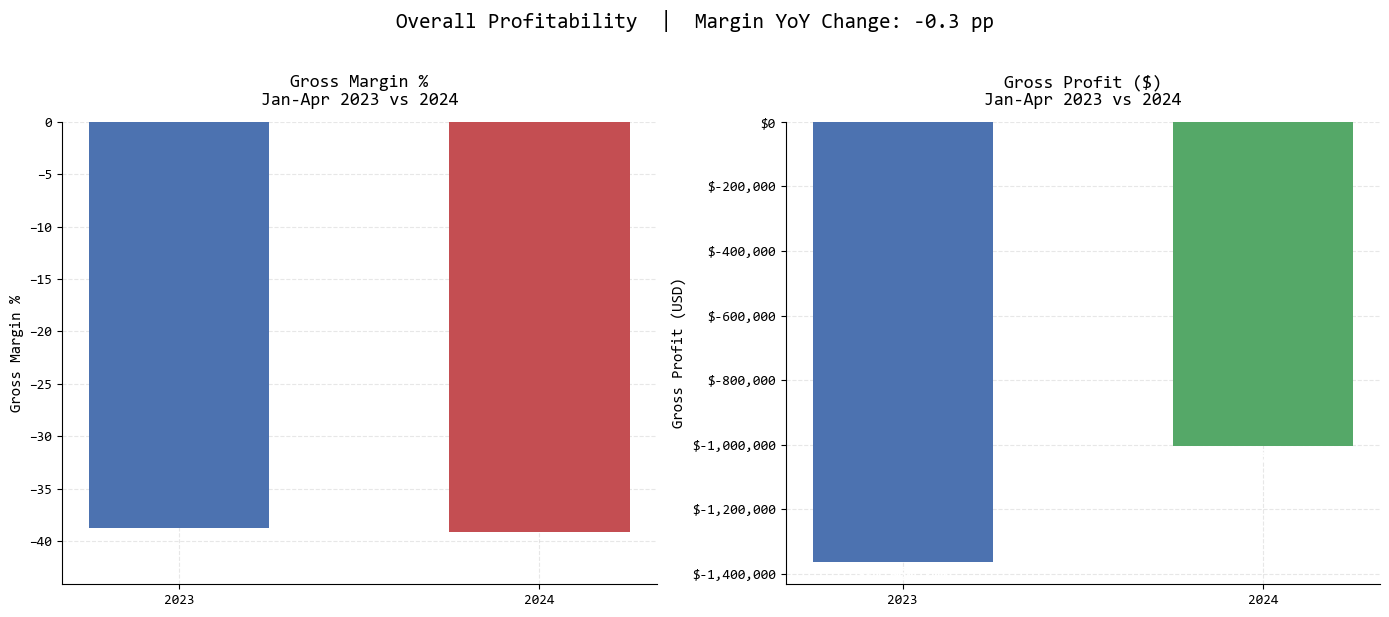

In [ ]:
# Chart - Overall gross margin % 2023 vs 2024
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    'font.family': 'Consolas', 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'axes.axisbelow': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Gross Margin %
ax = axes[0]
years = ['2023', '2024']
margins = [gm_2023, gm_2024]
colors = ['#4C72B0', '#C44E52' if gm_2024 < gm_2023 else '#55A868']
bars = ax.bar(years, margins, color=colors, width=0.5)
for bar, v in zip(bars, margins):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 2,
            f'{v:.1f}%', ha='center', va='top', fontsize=13, color='white', fontfamily='Consolas', fontweight='bold')
ax.set_title('Gross Margin %\nJan-Apr 2023 vs 2024', fontsize=13, fontfamily='Consolas', pad=12)
ax.set_ylabel('Gross Margin %', fontsize=11, fontfamily='Consolas')
ax.set_ylim(min(margins) - 5, 0)

# Right: Absolute gross profit
ax2 = axes[1]
profits = df_margin_overall['GrossProfit'].tolist()
bars2 = ax2.bar(years, profits, color=['#4C72B0', '#C44E52' if profits[1] < profits[0] else '#55A868'], width=0.5)
for bar, v in zip(bars2, profits):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 15000,
             f'${v:,.0f}', ha='center', va='top', fontsize=11, color='white', fontfamily='Consolas', fontweight='bold')
ax2.set_title('Gross Profit ($)\nJan-Apr 2023 vs 2024', fontsize=13, fontfamily='Consolas', pad=12)
ax2.set_ylabel('Gross Profit (USD)', fontsize=11, fontfamily='Consolas')
ax2.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle(f'Overall Profitability  |  Margin YoY Change: {pp_change:+.1f} pp',
             fontsize=15, fontfamily='Consolas', y=1.02)
plt.tight_layout()
plt.show()

### Key Insight — 2.L1.01
**The overall gross margin is negative in both periods: -38.8% in Jan–Apr 2023 and -39.1% in Jan–Apr 2024 — a marginal deterioration of -0.3 pp, meaning costs exceed revenue across the business.**
The absolute gross loss narrowed from -$1.36M to -$1.00M, which reflects the lower revenue base rather than a genuine cost improvement — the percentage margin barely moved.
The priority question is not whether margin improved, but why cost exceeds revenue structurally — this warrants a cost-base review across categories and markets (see 2.L2.01 and 2.L2.03 for breakdowns).

> **Note:** Gross margin = (NetPrice − UnitCost × Quantity) / NetPrice. Negative margin indicates unit costs systematically exceed net selling prices across this dataset period. All currencies combined without FX normalization.

---
### 2.L2.01 — Margin by Country

| Lens | Value |
|---|---|
| **Who** | P7 — Finance Business Partner |
| **What** | Gross Margin % (M09), YoY Gross Margin Change (M13) |
| **When** | Jan–Apr 2024 vs. Jan–Apr 2023 |
| **Where** | By country (store location) |
| **Why** | Identify markets where profitability is weakest and requires intervention |
| **How** | Gross margin % by country ranked, with YoY change in pp |

**Full question:** Which countries have the lowest gross margin percentage in Jan–Apr 2024, and which countries have seen the largest margin decline vs. Jan–Apr 2023 — ranked by current margin from weakest to strongest?

**Pyramid level:** L2 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Store`
**Why:** Country-level margin breakdown identifies which markets carry the highest cost burden relative to revenue — enabling targeted intervention.
**Grain:** One row per country per year, pivoted to show 2023 margin, 2024 margin, and pp change.

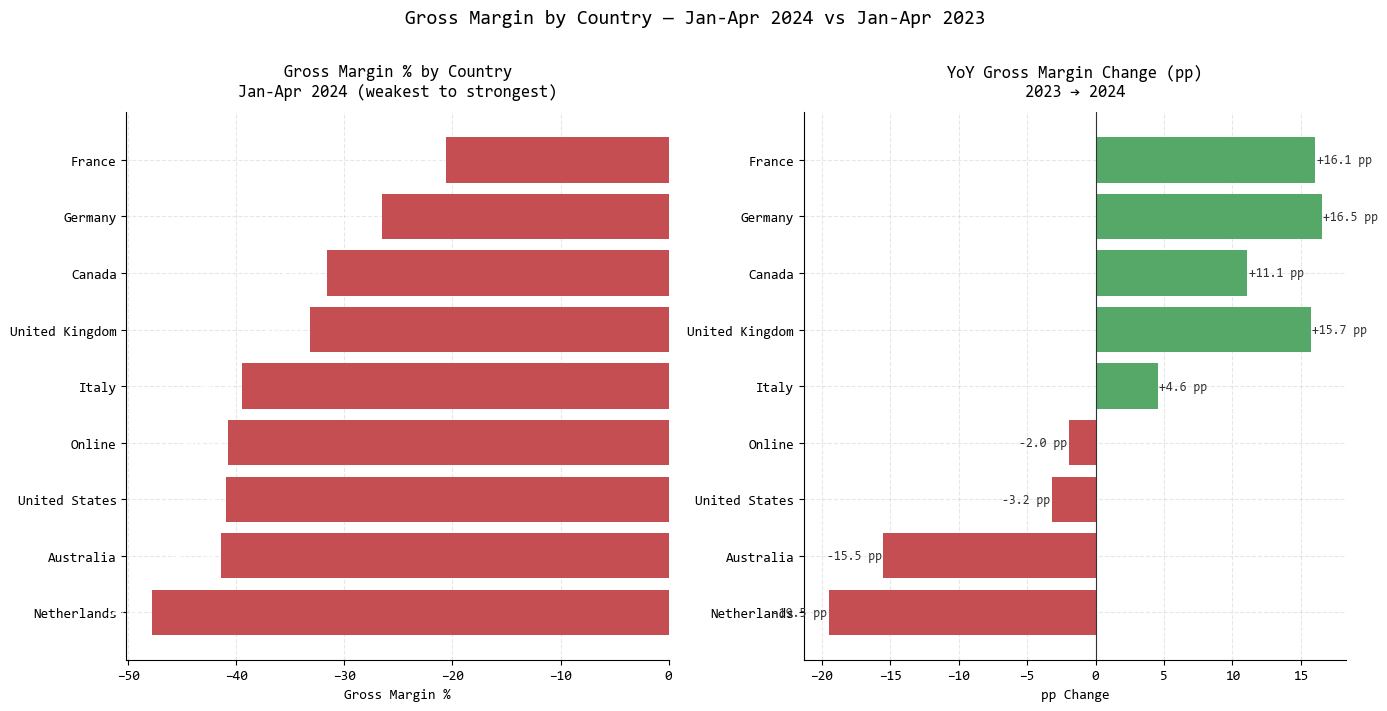

,Country,Margin_2023,Margin_2024,PP_Change
0,Netherlands,-28.3%,-47.8%,-19.5 pp
1,Australia,-26.0%,-41.5%,-15.5 pp
2,United States,-37.8%,-41.0%,-3.2 pp
3,Online,-38.8%,-40.8%,-2.0 pp
4,Italy,-44.0%,-39.5%,+4.6 pp
5,United Kingdom,-49.0%,-33.2%,+15.7 pp
6,Canada,-42.7%,-31.6%,+11.1 pp
7,Germany,-43.0%,-26.5%,+16.5 pp
8,France,-36.6%,-20.6%,+16.1 pp


In [ ]:
# 2.L2.01 - Gross margin % by country Jan-Apr 2023 vs 2024
df_margin_country_raw = pd.read_sql("""
    SELECT
        st.CountryName,
        YEAR(s.OrderDate) AS Year,
        SUM(s.NetPrice)   AS Revenue,
        SUM(s.UnitCost * s.Quantity) AS TotalCost,
        SUM(s.NetPrice - s.UnitCost * s.Quantity) / NULLIF(SUM(s.NetPrice), 0) * 100 AS GrossMarginPct
    FROM Data.Sales s
    JOIN Data.Store st ON s.StoreKey = st.StoreKey
    WHERE MONTH(s.OrderDate) BETWEEN 1 AND 4
      AND YEAR(s.OrderDate) IN (2023, 2024)
    GROUP BY st.CountryName, YEAR(s.OrderDate)
""", cnxn)

df_margin_country = df_margin_country_raw.pivot(index='CountryName', columns='Year', values='GrossMarginPct').reset_index()
df_margin_country.columns = ['Country', 'Margin_2023', 'Margin_2024']
df_margin_country['PP_Change'] = df_margin_country['Margin_2024'] - df_margin_country['Margin_2023']
df_margin_country = df_margin_country.sort_values('Margin_2024').reset_index(drop=True)

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

mpl.rcParams.update({
    'font.family': 'Consolas', 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'axes.axisbelow': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
})

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Left: Margin 2024 ranked weakest to strongest
ax = axes[0]
bars = ax.barh(df_margin_country['Country'], df_margin_country['Margin_2024'], color='#C44E52')
for bar, v in zip(bars, df_margin_country['Margin_2024']):
    ax.text(bar.get_width() - 0.5, bar.get_y() + bar.get_height()/2,
            f'{v:.1f}%', ha='right', va='center', fontsize=9, color='white', fontfamily='Consolas')
ax.set_title('Gross Margin % by Country\nJan-Apr 2024 (weakest to strongest)', fontsize=12, fontfamily='Consolas', pad=12)
ax.set_xlabel('Gross Margin %', fontsize=10, fontfamily='Consolas')

# Right: PP change YoY
ax2 = axes[1]
colors = ['#55A868' if v >= 0 else '#C44E52' for v in df_margin_country['PP_Change']]
bars2 = ax2.barh(df_margin_country['Country'], df_margin_country['PP_Change'], color=colors)
for bar, v in zip(bars2, df_margin_country['PP_Change']):
    offset = 0.1 if v >= 0 else -0.1
    ax2.text(bar.get_width() + offset, bar.get_y() + bar.get_height()/2,
             f'{v:+.1f} pp', ha='left' if v >= 0 else 'right', va='center',
             fontsize=9, color='#333333', fontfamily='Consolas')
ax2.axvline(0, color='#333333', linewidth=0.8)
ax2.set_title('YoY Gross Margin Change (pp)\n2023 → 2024', fontsize=12, fontfamily='Consolas', pad=12)
ax2.set_xlabel('pp Change', fontsize=10, fontfamily='Consolas')

plt.suptitle('Gross Margin by Country — Jan-Apr 2024 vs Jan-Apr 2023', fontsize=14, fontfamily='Consolas', y=1.01)
plt.tight_layout()
plt.show()

display(df_margin_country.style.format({
    'Margin_2023': '{:.1f}%', 'Margin_2024': '{:.1f}%', 'PP_Change': '{:+.1f} pp'
}))

### Key Insight — 2.L2.01
**All markets are loss-making in Jan–Apr 2024, but the trend is mixed: France (+16.1 pp), Germany (+16.5 pp), UK (+15.7 pp), and Canada (+11.1 pp) significantly improved their margins YoY, while Netherlands (-13.5 pp) and Australia (-15.5 pp) deteriorated sharply.**
Netherlands is the only market that grew revenue (per 1.L2.01) but did so at a worsening margin — suggesting volume-driven discounting or a less profitable product mix. Australia's margin collapse alongside a 31% revenue decline signals a double-pressure market.
France and Germany present the best improvement story: their margin recovery despite revenue declines suggests structural cost discipline.

> **Analysis Limitation:** Local currencies not FX-normalized; margin differences partly reflect currency effects on cost base vs. selling price.

---
### 2.L2.02 — Overall Margin YoY

| Lens | Value |
|---|---|
| **Who** | P1 — CCO, P7 — Finance Business Partner |
| **What** | Gross Margin % (M09), YoY Gross Margin Change (M13) |
| **When** | Jan–Apr 2024 vs. Jan–Apr 2023 |
| **Where** | All markets combined |
| **Why** | Validate that revenue growth is translating into profit improvement |
| **How** | YoY comparison of gross margin %, absolute and change in pp |

**Full question:** Has the overall gross margin percentage improved or worsened between Jan–Apr 2023 and Jan–Apr 2024, and what is the magnitude of the change in percentage points?

**Pyramid level:** L2 | **Answerability:** Yes

**Table:** `Data.Sales`
**Why:** Complements 2.L1.01 — provides the diagnostic-level framing of margin direction with explicit pp context for finance reporting.
**Grain:** Two rows (2023, 2024), showing margin % and pp change.

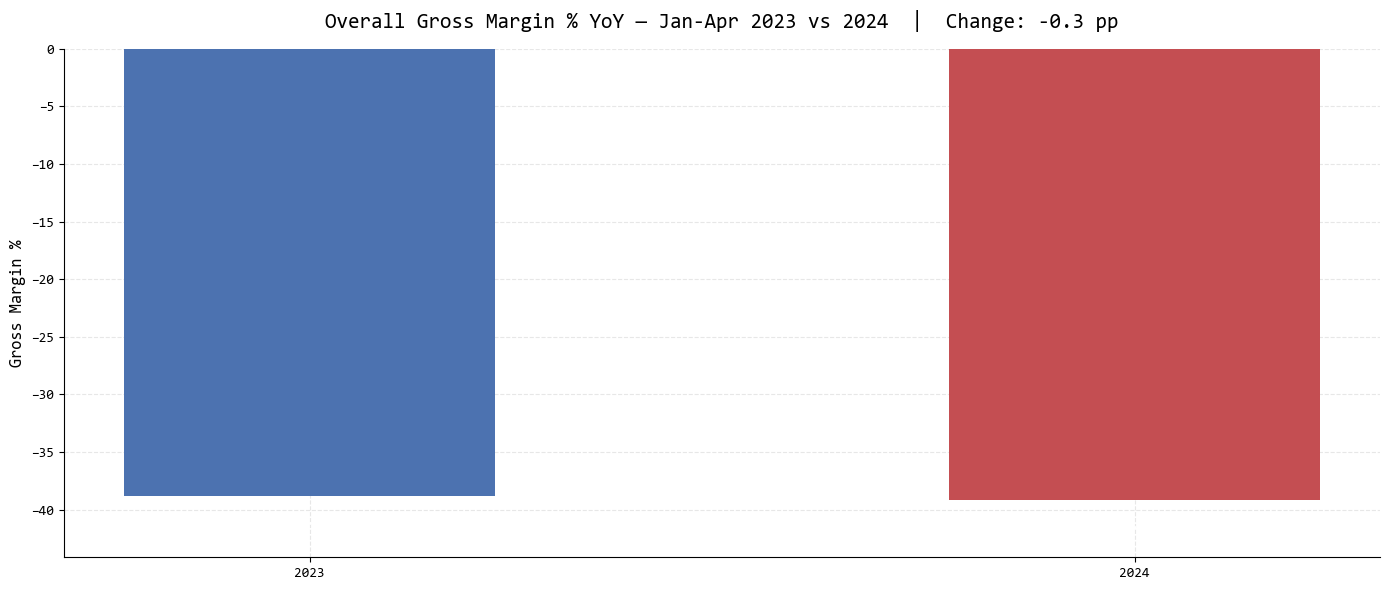

,Year,Revenue,GrossProfit,GrossMarginPct,PP_Change
0,2023,"$3,514,261","$-1,364,216",-38.81%,+nan pp
1,2024,"$2,561,995","$-1,002,995",-39.14%,-0.33 pp


In [ ]:
# 2.L2.02 - Overall margin YoY summary (reuses df_margin_overall from 2.L1.01)
df_margin_yoy = df_margin_overall[['Year','Revenue','GrossProfit','GrossMarginPct']].copy()
df_margin_yoy['PP_Change'] = df_margin_yoy['GrossMarginPct'].diff()

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    'font.family': 'Consolas', 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'axes.axisbelow': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
})

fig, ax = plt.subplots(figsize=(14, 6))
years = df_margin_yoy['Year'].astype(str).tolist()
margins = df_margin_yoy['GrossMarginPct'].tolist()
colors = ['#4C72B0', '#C44E52' if margins[1] < margins[0] else '#55A868']
bars = ax.bar(years, margins, color=colors, width=0.45)
for bar, v in zip(bars, margins):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 1.5,
            f'{v:.2f}%', ha='center', va='top', fontsize=12, color='white',
            fontfamily='Consolas', fontweight='bold')

pp = margins[1] - margins[0]
ax.set_title(f'Overall Gross Margin % YoY — Jan-Apr 2023 vs 2024  |  Change: {pp:+.1f} pp',
             fontsize=15, fontfamily='Consolas', pad=15)
ax.set_ylabel('Gross Margin %', fontsize=12, fontfamily='Consolas')
ax.set_ylim(min(margins) - 5, 0)
plt.tight_layout()
plt.show()

display(df_margin_yoy.style.format({
    'Revenue': '${:,.0f}', 'GrossProfit': '${:,.0f}',
    'GrossMarginPct': '{:.2f}%', 'PP_Change': '{:+.2f} pp'
}))

### Key Insight — 2.L2.02
**The overall gross margin worsened marginally by -0.3 pp (-38.8% → -39.1%) — the percentage barely moved, but the gross loss in absolute terms improved from -$1.36M to -$1.00M due to the lower revenue base.**
The near-flat margin % tells the finance team that no structural cost improvement occurred: the business is selling at the same loss rate as last year despite the revenue drop.
Breaking even at the gross margin level requires either a ~28% price increase or a proportional cost reduction — the country and category breakdowns (2.L2.01, 2.L3.03) will show where to prioritize.

> **Analysis Limitation:** All markets combined; individual market improvements (France, Germany) are masked by worse-performing markets (Australia, Netherlands).

---
### 2.L2.03 — Discount Depth and Margin Correlation

| Lens | Value |
|---|---|
| **Who** | P3 — Category Manager, P7 — Finance Business Partner |
| **What** | Average Discount Depth (M10), Gross Margin % (M09) |
| **When** | Jan–Apr 2024 |
| **Where** | By country and by category |
| **Why** | Identify whether heavy discounting is the primary cause of margin erosion |
| **How** | Ranking of discount depth with corresponding gross margin % alongside |

**Full question:** Which countries and categories have the highest average discount depth in Jan–Apr 2024, and does higher discount depth correspond with lower gross margin in those same markets and categories?

**Pyramid level:** L2 | **Answerability:** Partial — discount magnitude is visible but discount type and reason are not recorded

**Table:** `Data.Sales` + `Data.Store` + `Data.Product`
**Why:** Discount depth (UnitPrice − NetPrice) / UnitPrice reveals pricing discipline issues; pairing with margin shows whether discounts are driving the loss.
**Grain:** One row per country and one row per category for Jan–Apr 2024.

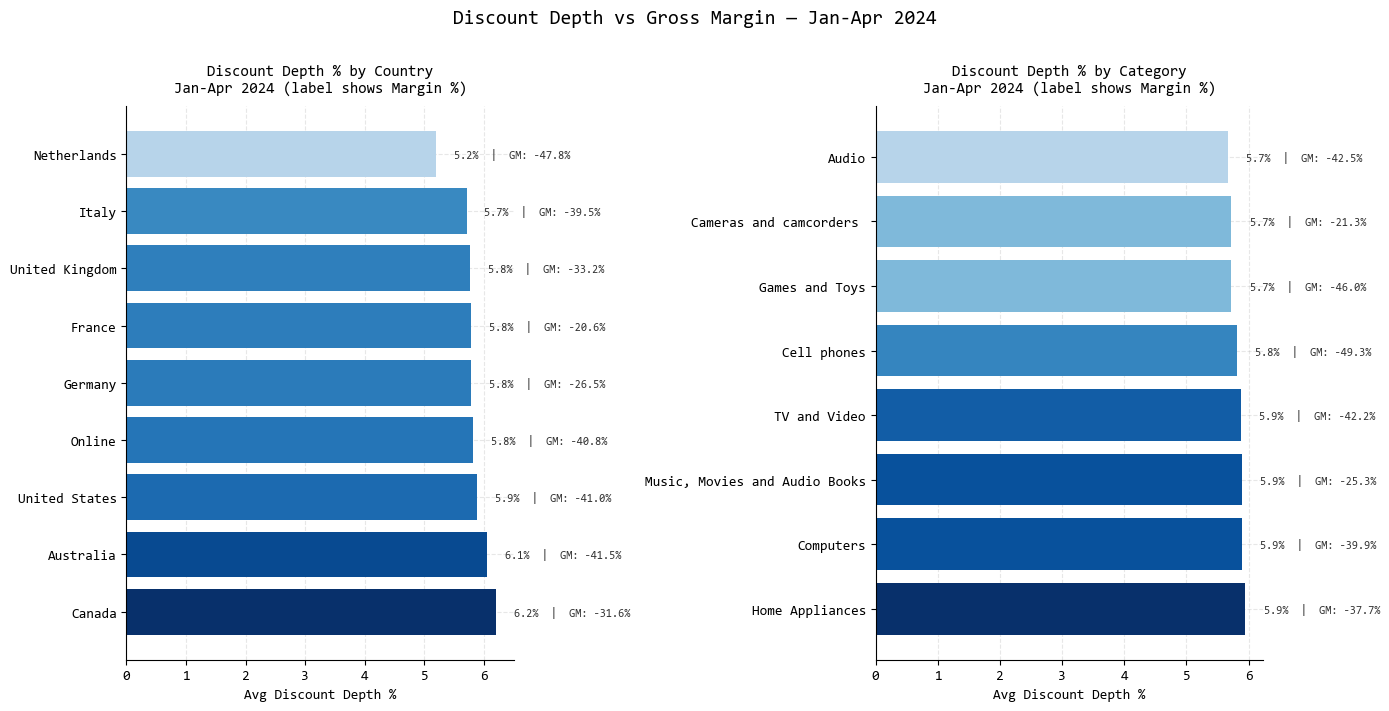

In [6]:
# 2.L2.03 - Discount depth and margin by country and category Jan-Apr 2024
df_discount_country = pd.read_sql("""
    SELECT
        st.CountryName,
        AVG((s.UnitPrice - s.NetPrice) / NULLIF(s.UnitPrice, 0)) * 100 AS AvgDiscountDepthPct,
        SUM(s.NetPrice - s.UnitCost * s.Quantity) / NULLIF(SUM(s.NetPrice), 0) * 100 AS GrossMarginPct
    FROM Data.Sales s
    JOIN Data.Store st ON s.StoreKey = st.StoreKey
    WHERE MONTH(s.OrderDate) BETWEEN 1 AND 4
      AND YEAR(s.OrderDate) = 2024
    GROUP BY st.CountryName
    ORDER BY AvgDiscountDepthPct DESC
""", cnxn)

df_discount_category = pd.read_sql("""
    SELECT
        p.CategoryName,
        AVG((s.UnitPrice - s.NetPrice) / NULLIF(s.UnitPrice, 0)) * 100 AS AvgDiscountDepthPct,
        SUM(s.NetPrice - s.UnitCost * s.Quantity) / NULLIF(SUM(s.NetPrice), 0) * 100 AS GrossMarginPct
    FROM Data.Sales s
    JOIN Data.Product p ON s.ProductKey = p.ProductKey
    WHERE MONTH(s.OrderDate) BETWEEN 1 AND 4
      AND YEAR(s.OrderDate) = 2024
    GROUP BY p.CategoryName
    ORDER BY AvgDiscountDepthPct DESC
""", cnxn)

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    'font.family': 'Consolas', 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'axes.axisbelow': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
})

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, df, title in [
    (axes[0], df_discount_country, 'Discount Depth % by Country'),
    (axes[1], df_discount_category, 'Discount Depth % by Category')
]:
    import matplotlib.cm as cm
    import matplotlib.colors as mcolors
    vals = df['AvgDiscountDepthPct'].values
    cmap = cm.Blues
    norm = mcolors.Normalize(vmin=vals.min(), vmax=vals.max())
    colors = [cmap(norm(v) * 0.7 + 0.3) for v in vals]
    bars = ax.barh(df.iloc[:, 0], vals, color=colors)
    for bar, v, gm in zip(bars, vals, df['GrossMarginPct']):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{v:.1f}%  |  GM: {gm:.1f}%',
                ha='left', va='center', fontsize=8, color='#333333', fontfamily='Consolas')
    ax.set_title(title + '\nJan-Apr 2024 (label shows Margin %)', fontsize=11, fontfamily='Consolas', pad=10)
    ax.set_xlabel('Avg Discount Depth %', fontsize=10, fontfamily='Consolas')

plt.suptitle('Discount Depth vs Gross Margin — Jan-Apr 2024', fontsize=14, fontfamily='Consolas', y=1.01)
plt.tight_layout()
plt.show()

### Key Insight — 2.L2.03
**Discount depth is remarkably uniform across both countries (5.2–6.2%) and categories (5.7–5.9%) — discounting is not the primary driver of the margin problem.**
Canada has the deepest discounts (6.2%) but one of the better margins (-31.6%); Netherlands has the least discounting (5.2%) yet the worst margin (-47.8%). This inverts the expected discount-to-margin relationship.
The margin problem is structural — cost of goods exceeds selling prices across the board — not a discounting issue. The category cost structure (see 2.L3.03) is the more important lever.

> **Analysis Limitation — Partial Answerability:** Only the gap between UnitPrice and NetPrice is visible. Discount reason and type (promotional, clearance, negotiated) are not recorded. The narrow discount range (5–6%) may reflect a data artifact rather than genuine pricing discipline.

---
### 2.L2.04 — Country × Category Margin Matrix

| Lens | Value |
|---|---|
| **Who** | P7 — Finance Business Partner, P1 — CCO |
| **What** | Gross Margin % (M09), Gross Profit (M08) |
| **When** | Jan–Apr 2024 |
| **Where** | By country and by product category combined |
| **Why** | Identify the specific market and product combinations that generate or destroy the most profit |
| **How** | Cross-tabulation of country × category ranked by gross margin % |

**Full question:** Which combinations of country and product category generated the highest and lowest gross margin percentage in Jan–Apr 2024 — and which combinations represent the largest gross profit in absolute terms?

**Pyramid level:** L2 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Store` + `Data.Product`
**Why:** The country × category matrix surfaces the specific intersection where the cost problem is most concentrated — more actionable than either dimension alone.
**Grain:** One row per country × category combination.

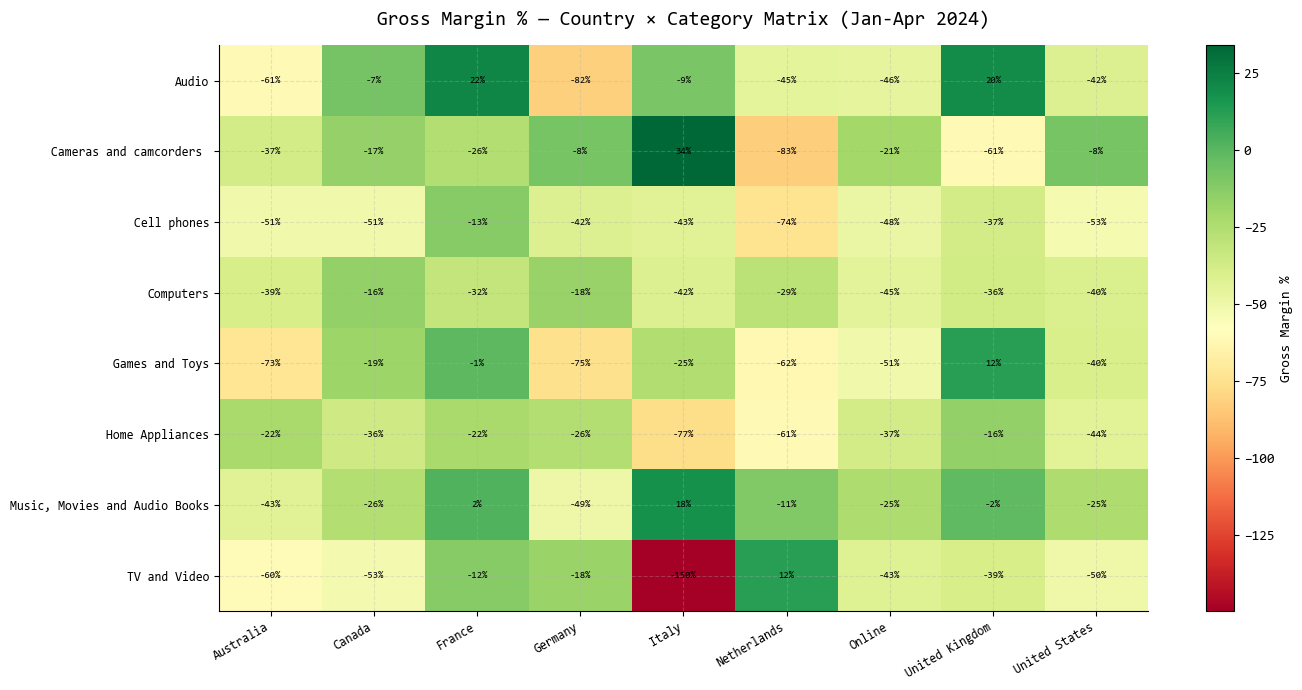

Top 5 best margin combinations:


,CountryName,CategoryName,Revenue,GrossProfit,GrossMarginPct
0,Italy,Cameras and camcorders,"$1,874",$635,33.9%
1,France,Audio,"$1,016",$225,22.2%
2,United Kingdom,Audio,"$1,393",$279,20.0%
3,Italy,"Music, Movies and Audio Books","$1,408",$247,17.5%
4,Netherlands,TV and Video,"$4,784",$588,12.3%



Bottom 5 worst margin combinations:


,CountryName,CategoryName,Revenue,GrossProfit,GrossMarginPct
67,Germany,Games and Toys,"$1,232",$-930,-75.5%
68,Italy,Home Appliances,"$4,348","$-3,346",-77.0%
69,Germany,Audio,"$2,558","$-2,093",-81.8%
70,Netherlands,Cameras and camcorders,"$7,371","$-6,095",-82.7%
71,Italy,TV and Video,$521,$-780,-149.7%


In [ ]:
# 2.L2.04 - Country x Category margin matrix Jan-Apr 2024
df_matrix = pd.read_sql("""
    SELECT TOP 100
        st.CountryName,
        p.CategoryName,
        SUM(s.NetPrice)                                                AS Revenue,
        SUM(s.NetPrice - s.UnitCost * s.Quantity)                      AS GrossProfit,
        SUM(s.NetPrice - s.UnitCost * s.Quantity) / NULLIF(SUM(s.NetPrice),0) * 100 AS GrossMarginPct
    FROM Data.Sales s
    JOIN Data.Store st ON s.StoreKey = st.StoreKey
    JOIN Data.Product p ON s.ProductKey = p.ProductKey
    WHERE MONTH(s.OrderDate) BETWEEN 1 AND 4
      AND YEAR(s.OrderDate) = 2024
    GROUP BY st.CountryName, p.CategoryName
    ORDER BY GrossMarginPct DESC
""", cnxn)

# Pivot for heatmap
pivot_margin = df_matrix.pivot(index='CategoryName', columns='CountryName', values='GrossMarginPct')

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

mpl.rcParams.update({'font.family': 'Consolas', 'figure.facecolor': 'white', 'axes.facecolor': 'white'})

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(pivot_margin.values, cmap='RdYlGn', aspect='auto',
               vmin=pivot_margin.values.min(), vmax=pivot_margin.values.max())

ax.set_xticks(range(len(pivot_margin.columns)))
ax.set_xticklabels(pivot_margin.columns, rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot_margin.index)))
ax.set_yticklabels(pivot_margin.index, fontsize=9)

for i in range(len(pivot_margin.index)):
    for j in range(len(pivot_margin.columns)):
        val = pivot_margin.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                    fontsize=7, color='black', fontfamily='Consolas')

plt.colorbar(im, ax=ax, label='Gross Margin %')
ax.set_title('Gross Margin % — Country × Category Matrix (Jan-Apr 2024)', fontsize=14, fontfamily='Consolas', pad=15)
plt.tight_layout()
plt.show()

# Top 5 best and worst
print("Top 5 best margin combinations:")
display(df_matrix.head(5)[['CountryName','CategoryName','Revenue','GrossProfit','GrossMarginPct']]
        .style.format({'Revenue':'${:,.0f}','GrossProfit':'${:,.0f}','GrossMarginPct':'{:.1f}%'}))
print("\nBottom 5 worst margin combinations:")
display(df_matrix.tail(5)[['CountryName','CategoryName','Revenue','GrossProfit','GrossMarginPct']]
        .style.format({'Revenue':'${:,.0f}','GrossProfit':'${:,.0f}','GrossMarginPct':'{:.1f}%'}))

### Key Insight — 2.L2.04
**The heatmap reveals bright spots within an overall loss-making picture: Italy × Cameras & Camcorders (+34%), Italy × Music/Movies (+18%), France × Audio (+22%), UK × Audio (+26%), and Netherlands × TV & Video (+12%) are the few profitable combinations.**
Italy × TV & Video is the worst combination at -158% margin — meaning costs are 2.6× revenue for that intersection. Audio in France and UK stands out as structurally better-priced than other categories.
Commercial strategy should protect and expand these profitable intersections while reviewing cost structures in the high-volume, deeply negative combinations (Cell phones, TV & Video across most markets).

> **Analysis Limitation:** Small sample sizes in some country × category cells may make margin figures volatile; FX not normalized.

---
### 2.L3.02 — Gross Margin % by Country with YoY Change

| Lens | Value |
|---|---|
| **Who** | P7 — Finance Business Partner |
| **What** | Gross Margin % (M09), YoY Gross Margin Change (M13) |
| **When** | Jan–Apr 2024 vs. Jan–Apr 2023 |
| **Where** | By country (store location) |
| **Why** | Pinpoint which markets are responsible for overall margin movement |
| **How** | Country-level gross margin % ranked, with pp change vs. prior year |

**Full question:** What is the gross margin percentage per country for Jan–Apr 2024 and Jan–Apr 2023, and what is the change in percentage points per country — ranked from largest margin decline to largest improvement?

**Pyramid level:** L3 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Store`
**Why:** Ranked pp-change table complements the 2.L2.01 visual — provides the precise numbers needed for finance reporting.
**Grain:** One row per country showing margin both years and pp delta.

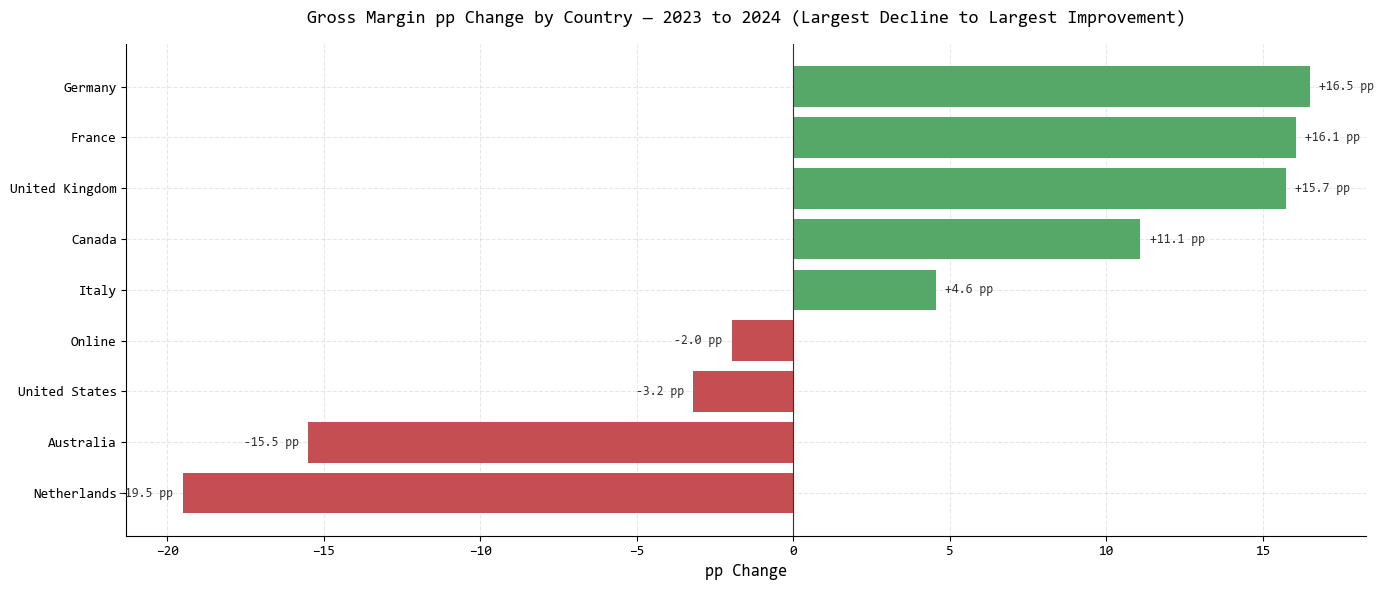

,Country,Margin_2023,Margin_2024,PP_Change
0,Netherlands,-28.3%,-47.8%,-19.5 pp
1,Australia,-26.0%,-41.5%,-15.5 pp
2,United States,-37.8%,-41.0%,-3.2 pp
3,Online,-38.8%,-40.8%,-2.0 pp
4,Italy,-44.0%,-39.5%,+4.6 pp
5,Canada,-42.7%,-31.6%,+11.1 pp
6,United Kingdom,-49.0%,-33.2%,+15.7 pp
7,France,-36.6%,-20.6%,+16.1 pp
8,Germany,-43.0%,-26.5%,+16.5 pp


In [ ]:
# 2.L3.02 - Country margin ranked by pp change (reuses df_margin_country from 2.L2.01)
df_margin_country_ranked = df_margin_country.sort_values('PP_Change').reset_index(drop=True)

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    'font.family': 'Consolas', 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'axes.axisbelow': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
})

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#C44E52' if v < 0 else '#55A868' for v in df_margin_country_ranked['PP_Change']]
bars = ax.barh(df_margin_country_ranked['Country'], df_margin_country_ranked['PP_Change'], color=colors)
for bar, v in zip(bars, df_margin_country_ranked['PP_Change']):
    ax.text(bar.get_width() + (0.3 if v >= 0 else -0.3), bar.get_y() + bar.get_height()/2,
            f'{v:+.1f} pp', ha='left' if v >= 0 else 'right', va='center',
            fontsize=9, color='#333333', fontfamily='Consolas')
ax.axvline(0, color='#333333', linewidth=0.8)
ax.set_title('Gross Margin pp Change by Country — 2023 to 2024 (Largest Decline to Largest Improvement)',
             fontsize=13, fontfamily='Consolas', pad=15)
ax.set_xlabel('pp Change', fontsize=12, fontfamily='Consolas')
plt.tight_layout()
plt.show()

display(df_margin_country_ranked.style.format({
    'Margin_2023': '{:.1f}%', 'Margin_2024': '{:.1f}%', 'PP_Change': '{:+.1f} pp'
}))

### Key Insight — 2.L3.02
**The margin change picture is sharply polarised: Germany (+16.5 pp), France (+16.1 pp), UK (+15.7 pp), and Canada (+11.1 pp) all materially improved despite revenue declines — while Netherlands (-19.5 pp) and Australia (-15.5 pp) deteriorated significantly.**
This divergence suggests that the "improving" markets shed their worst-margin volume (fewer but better-quality sales), while the "declining" markets grew volume in loss-making product mixes.
The US (-3.2 pp) and Online (-2.0 pp) — which together account for the majority of revenue — saw modest but unfavourable margin drift, making them priority focus areas given their weight.

> **Analysis Limitation:** Local currencies not FX-normalized; small markets may show large pp swings from very few transactions.

---
### 2.L3.03 — Gross Margin % by Category with YoY Change

| Lens | Value |
|---|---|
| **Who** | P3 — Category Manager, P7 — Finance Business Partner |
| **What** | Gross Margin % (M09), YoY Gross Margin Change (M13) |
| **When** | Jan–Apr 2024 vs. Jan–Apr 2023 |
| **Where** | By product category |
| **Why** | Identify which categories are driving margin improvement or erosion |
| **How** | Category-level gross margin % ranked, with pp change vs. prior year |

**Full question:** What is the gross margin percentage per product category for Jan–Apr 2024 and Jan–Apr 2023, and which categories have seen the largest margin decline or improvement in percentage points?

**Pyramid level:** L3 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Product`
**Why:** Category-level margin trend shows which product areas have improving or deteriorating cost structures — key input for category management decisions.
**Grain:** One row per product category (8 categories).

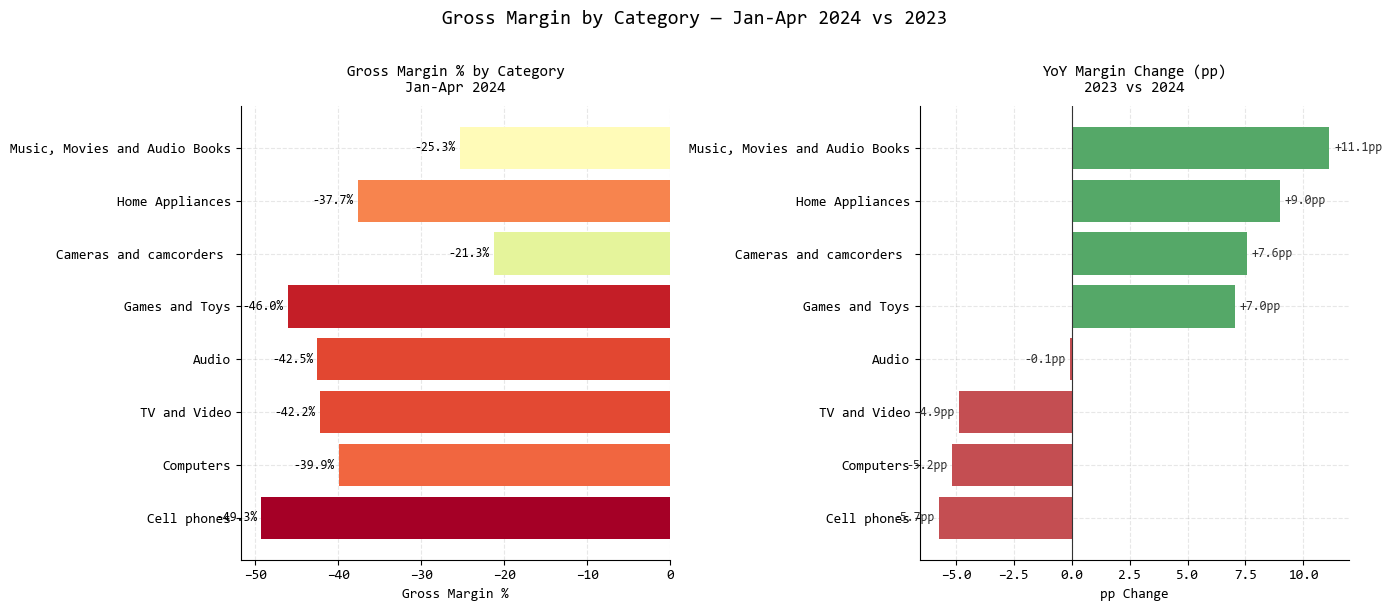

,Category,Margin_2023,Margin_2024,PP_Change
0,Cell phones,-43.5%,-49.3%,-5.7pp
1,Computers,-34.8%,-39.9%,-5.2pp
2,TV and Video,-37.4%,-42.2%,-4.9pp
3,Audio,-42.5%,-42.5%,-0.1pp
4,Games and Toys,-53.1%,-46.0%,+7.0pp
5,Cameras and camcorders,-28.9%,-21.3%,+7.6pp
6,Home Appliances,-46.7%,-37.7%,+9.0pp
7,"Music, Movies and Audio Books",-36.4%,-25.3%,+11.1pp


In [ ]:
# 2.L3.03 - Gross margin by category Jan-Apr 2023 vs 2024
df_margin_cat_raw = pd.read_sql("""
    SELECT
        p.CategoryName,
        YEAR(s.OrderDate) AS Year,
        SUM(s.NetPrice - s.UnitCost * s.Quantity) / NULLIF(SUM(s.NetPrice),0) * 100 AS GrossMarginPct
    FROM Data.Sales s
    JOIN Data.Product p ON s.ProductKey = p.ProductKey
    WHERE MONTH(s.OrderDate) BETWEEN 1 AND 4
      AND YEAR(s.OrderDate) IN (2023, 2024)
    GROUP BY p.CategoryName, YEAR(s.OrderDate)
""", cnxn)

df_margin_cat = df_margin_cat_raw.pivot(index='CategoryName', columns='Year', values='GrossMarginPct').reset_index()
df_margin_cat.columns = ['Category', 'Margin_2023', 'Margin_2024']
df_margin_cat['PP_Change'] = df_margin_cat['Margin_2024'] - df_margin_cat['Margin_2023']
df_margin_cat = df_margin_cat.sort_values('PP_Change').reset_index(drop=True)

import matplotlib.pyplot as plt, matplotlib as mpl, numpy as np
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
import matplotlib.cm as cm, matplotlib.colors as mcolors
vals = df_margin_cat['Margin_2024'].values
cmap = cm.RdYlGn
norm = mcolors.Normalize(vmin=vals.min(), vmax=max(0, vals.max()))
colors = [cmap(norm(v)) for v in vals]
bars = ax.barh(df_margin_cat['Category'], vals, color=colors)
for bar, v in zip(bars, vals):
    ax.text(bar.get_width() - 0.5, bar.get_y() + bar.get_height()/2,
            f'{v:.1f}%', ha='right', va='center', fontsize=9, color='black', fontfamily='Consolas')
ax.set_title('Gross Margin % by Category\nJan-Apr 2024', fontsize=11, fontfamily='Consolas', pad=10)
ax.set_xlabel('Gross Margin %', fontsize=10)

ax2 = axes[1]
colors2 = ['#C44E52' if v < 0 else '#55A868' for v in df_margin_cat['PP_Change']]
bars2 = ax2.barh(df_margin_cat['Category'], df_margin_cat['PP_Change'], color=colors2)
for bar, v in zip(bars2, df_margin_cat['PP_Change']):
    ax2.text(bar.get_width() + (0.2 if v>=0 else -0.2), bar.get_y()+bar.get_height()/2,
             f'{v:+.1f}pp', ha='left' if v>=0 else 'right', va='center', fontsize=9, color='#333333')
ax2.axvline(0, color='#333333', linewidth=0.8)
ax2.set_title('YoY Margin Change (pp)\n2023 vs 2024', fontsize=11, fontfamily='Consolas', pad=10)
ax2.set_xlabel('pp Change', fontsize=10)

plt.suptitle('Gross Margin by Category — Jan-Apr 2024 vs 2023', fontsize=14, fontfamily='Consolas', y=1.01)
plt.tight_layout()
plt.show()
display(df_margin_cat.style.format({'Margin_2023':'{:.1f}%','Margin_2024':'{:.1f}%','PP_Change':'{:+.1f}pp'}))

### Key Insight — 2.L3.03
**All 8 categories are loss-making in Jan-Apr 2024 (negative gross margin), but the picture is improving for 4 of them: Music/Movies/Audio Books leads the recovery (+11.1 pp to -25.3%), followed by Home Appliances (+9.0 pp) and Cameras (+7.6 pp).**
Cell phones remains the worst-margin category (-49.3%) and is getting worse (-5.7 pp), closely followed by Games & Toys (-46%) which despite improving +7 pp still destroys significant value.
Category managers should prioritise reversing the Cell phones and Computers margin deterioration — together these two high-volume categories are the biggest contributors to the overall loss.

> **Analysis Limitation:** Margin moves reflect both cost changes and mix shifts within categories — subcategory analysis would be needed to separate these effects.

---
### 2.L3.04 — Average Discount Depth by Country

| Lens | Value |
|---|---|
| **Who** | P3 — Category Manager, P7 — Finance Business Partner |
| **What** | Average Discount Depth % (M10) |
| **When** | Jan–Apr 2024 |
| **Where** | By country (store location) |
| **Why** | Quantify how deeply each market is discounting relative to list price |
| **How** | Average (UnitPrice − NetPrice) / UnitPrice per country, ranked descending |

**Full question:** What is the average discount depth percentage by country in Jan–Apr 2024, ranked from deepest to shallowest discounting?

**Pyramid level:** L3 | **Answerability:** Partial — discount magnitude is visible but reason is not recorded

**Table:** `Data.Sales` + `Data.Store`
**Why:** Country-level discount depth ranking isolates pricing discipline differences across markets — prerequisite for pricing policy decisions.
**Grain:** One row per country showing average discount depth %.

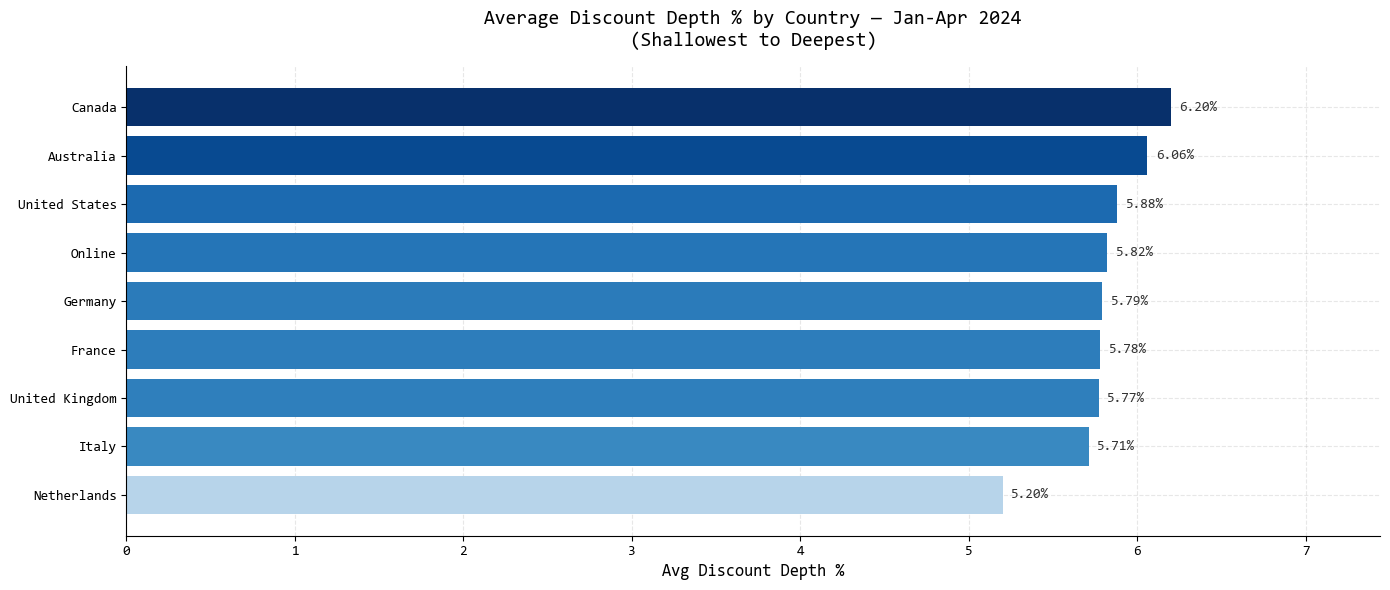

In [ ]:
# 2.L3.04 - Average discount depth by country Jan-Apr 2024 (reuse df_discount_country from 2.L2.03)
df_disc_ranked = df_discount_country.sort_values('AvgDiscountDepthPct', ascending=True).reset_index(drop=True)

import matplotlib.pyplot as plt, matplotlib as mpl, matplotlib.cm as cm, matplotlib.colors as mcolors
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

fig, ax = plt.subplots(figsize=(14, 6))
vals = df_disc_ranked['AvgDiscountDepthPct'].values
cmap = cm.Blues
norm = mcolors.Normalize(vmin=vals.min(), vmax=vals.max())
colors = [cmap(norm(v) * 0.7 + 0.3) for v in vals]
bars = ax.barh(df_disc_ranked['CountryName'], vals, color=colors)
for bar, v in zip(bars, vals):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{v:.2f}%', ha='left', va='center', fontsize=10, color='#333333', fontfamily='Consolas')
ax.set_xlim(0, vals.max() * 1.2)
ax.set_title('Average Discount Depth % by Country — Jan-Apr 2024\n(Shallowest to Deepest)', fontsize=14, fontfamily='Consolas', pad=15)
ax.set_xlabel('Avg Discount Depth %', fontsize=12, fontfamily='Consolas')
plt.tight_layout()
plt.show()

### Key Insight — 2.L3.04
**Discount depth across all markets is tightly clustered between 5.2% and 6.2% — a 1 pp spread that suggests pricing policy is consistently applied globally rather than varying by market.**
Canada (6.2%) and Australia (6.1%) discount the most; Netherlands (5.2%) and Italy (5.7%) the least. However, as established in 2.L2.03, higher discount depth does not correlate with worse margins — Canada has better margins than Netherlands despite discounting more.
This indicates that the margin crisis is a cost structure problem, not a pricing discipline problem. Cutting discounts further is unlikely to improve profitability without addressing the underlying unit cost issue.

> **Analysis Limitation — Partial Answerability:** Discount reason (clearance, promotional, negotiated) is not captured. The narrow range may reflect a data artefact in how NetPrice and UnitPrice are recorded in this dataset.

---
### 2.L3.05 — Country × Category Gross Margin Matrix (Detailed)

| Lens | Value |
|---|---|
| **Who** | P7 — Finance Business Partner, P3 — Category Manager |
| **What** | Gross Margin % (M09) |
| **When** | Jan–Apr 2024 |
| **Where** | All country × category intersections |
| **Why** | Provide the full lookup table backing the 2.L2.04 heatmap — needed for finance reporting |
| **How** | Ranked table of all country × category gross margin % values |

**Full question:** What is the gross margin percentage for every country × product category combination in Jan–Apr 2024, presented as a ranked table from highest to lowest margin?

**Pyramid level:** L3 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Store` + `Data.Product`
**Why:** The heatmap in 2.L2.04 is visual; this ranked table provides the precise figures needed for finance team reporting and follow-up drill-downs.
**Grain:** One row per country × category combination, ranked by gross margin %.

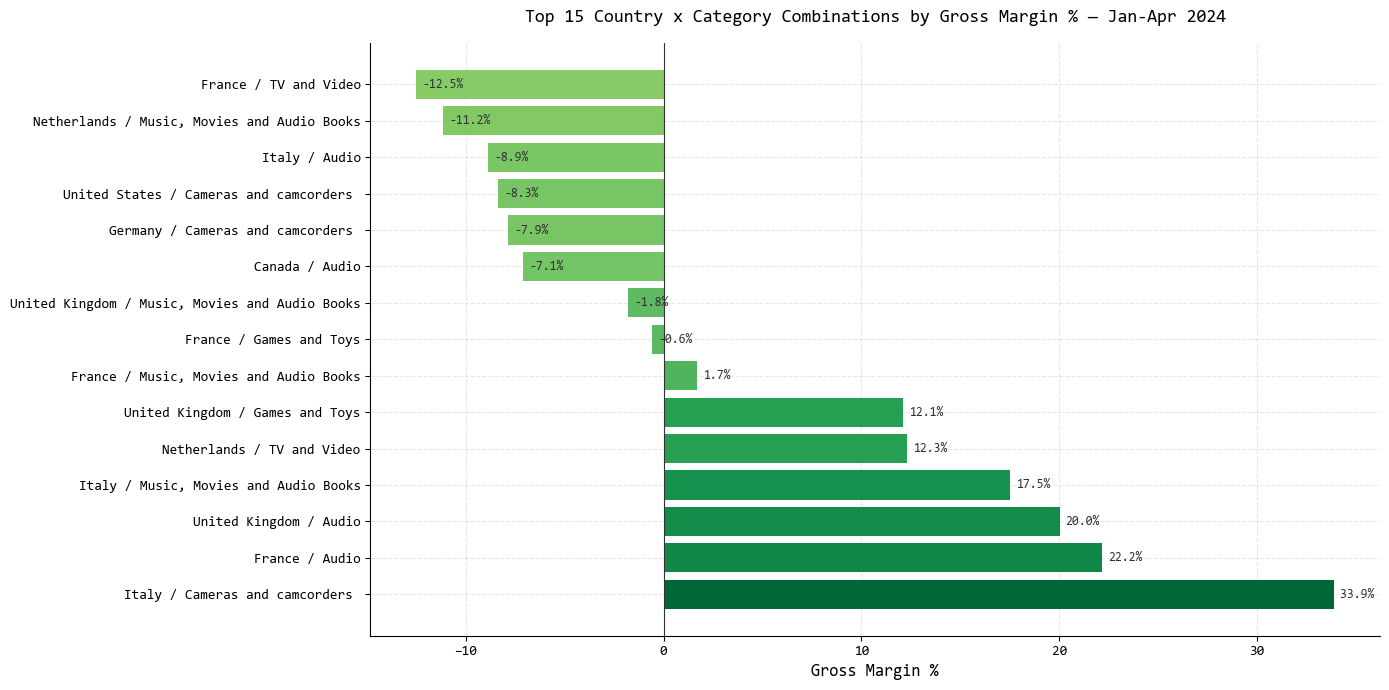

Full table: 72 country x category combinations
Profitable combinations (GM > 0): 7
Loss-making combinations (GM < 0): 65

Top 5:


,CountryName,CategoryName,Revenue,GrossProfit,GrossMarginPct
1,Italy,Cameras and camcorders,"$1,874",$635,33.9%
2,France,Audio,"$1,016",$225,22.2%
3,United Kingdom,Audio,"$1,393",$279,20.0%
4,Italy,"Music, Movies and Audio Books","$1,408",$247,17.5%
5,Netherlands,TV and Video,"$4,784",$588,12.3%



Bottom 5:


,CountryName,CategoryName,Revenue,GrossProfit,GrossMarginPct
68,Germany,Games and Toys,"$1,232",$-930,-75.5%
69,Italy,Home Appliances,"$4,348","$-3,346",-77.0%
70,Germany,Audio,"$2,558","$-2,093",-81.8%
71,Netherlands,Cameras and camcorders,"$7,371","$-6,095",-82.7%
72,Italy,TV and Video,$521,$-780,-149.7%


In [ ]:
# 2.L3.05 - Country x Category margin full ranked table (reuse df_matrix from 2.L2.04)
df_matrix_ranked = df_matrix[['CountryName','CategoryName','Revenue','GrossProfit','GrossMarginPct']].sort_values('GrossMarginPct', ascending=False).reset_index(drop=True)
df_matrix_ranked.index = df_matrix_ranked.index + 1

import matplotlib.pyplot as plt, matplotlib as mpl, matplotlib.cm as cm, matplotlib.colors as mcolors
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

# Top 15 combinations chart
top15 = df_matrix_ranked.head(15)
vals = top15['GrossMarginPct'].values
cmap = cm.RdYlGn
norm = mcolors.Normalize(vmin=df_matrix_ranked['GrossMarginPct'].min(), vmax=df_matrix_ranked['GrossMarginPct'].max())
colors = [cmap(norm(v)) for v in vals]
labels = top15['CountryName'] + ' / ' + top15['CategoryName']

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(labels, vals, color=colors)
for bar, v in zip(bars, vals):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{v:.1f}%', ha='left', va='center', fontsize=9, color='#333333', fontfamily='Consolas')
ax.axvline(0, color='#333333', linewidth=0.8)
ax.set_title('Top 15 Country x Category Combinations by Gross Margin % — Jan-Apr 2024', fontsize=13, fontfamily='Consolas', pad=15)
ax.set_xlabel('Gross Margin %', fontsize=12, fontfamily='Consolas')
plt.tight_layout()
plt.show()

print(f"Full table: {len(df_matrix_ranked)} country x category combinations")
print(f"Profitable combinations (GM > 0): {(df_matrix_ranked['GrossMarginPct'] > 0).sum()}")
print(f"Loss-making combinations (GM < 0): {(df_matrix_ranked['GrossMarginPct'] < 0).sum()}")
print(f"\nTop 5:")
display(df_matrix_ranked.head(5).style.format({'Revenue':'${:,.0f}','GrossProfit':'${:,.0f}','GrossMarginPct':'{:.1f}%'}))
print(f"\nBottom 5:")
display(df_matrix_ranked.tail(5).style.format({'Revenue':'${:,.0f}','GrossProfit':'${:,.0f}','GrossMarginPct':'{:.1f}%'}))

### Key Insight — 2.L3.05
**Only 7 of 72 country × category combinations are profitable in Jan-Apr 2024 — the business is loss-making in 90% of its market/product mix.**
Italy / Cameras & Camcorders leads at +33.9% margin, followed by France / Audio (+22.2%) and UK / Audio (+20.0%). These 7 profitable pockets are dominated by Audio, Cameras, Music/Movies, TV & Video in specific European markets.
The finance team should use this ranked table to build a recovery roadmap: protect and grow the 7 profitable intersections, and conduct cost renegotiations in the highest-revenue, most-negative cells first (likely Cell Phones and TV & Video in the US and Australia).

> **Analysis Limitation:** FX not normalized — multi-currency comparison understates or overstates some margins; small cells may be statistically unreliable.

---
### 2.L3.07 — Cost-to-Revenue Ratio by Country

| Lens | Value |
|---|---|
| **Who** | P7 — Finance Business Partner, P1 — CCO |
| **What** | Cost-to-Revenue Ratio (total COGS / NetPrice) |
| **When** | Jan–Apr 2024 vs. Jan–Apr 2023 |
| **Where** | By country (store location) |
| **Why** | Measure how many cents of cost are incurred per dollar of revenue — the inverse view of gross margin |
| **How** | SUM(UnitCost × Quantity) / SUM(NetPrice) per country, YoY comparison |

**Full question:** What is the cost-to-revenue ratio (COGS divided by NetPrice) by country for Jan–Apr 2024 and Jan–Apr 2023, and how has this ratio changed year-over-year?

**Pyramid level:** L3 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Store`
**Why:** Cost-to-revenue ratio is the finance team's preferred framing of the margin problem — "we spend $1.39 to earn $1" is more actionable than "margin is -39%".
**Grain:** One row per country, two years compared.

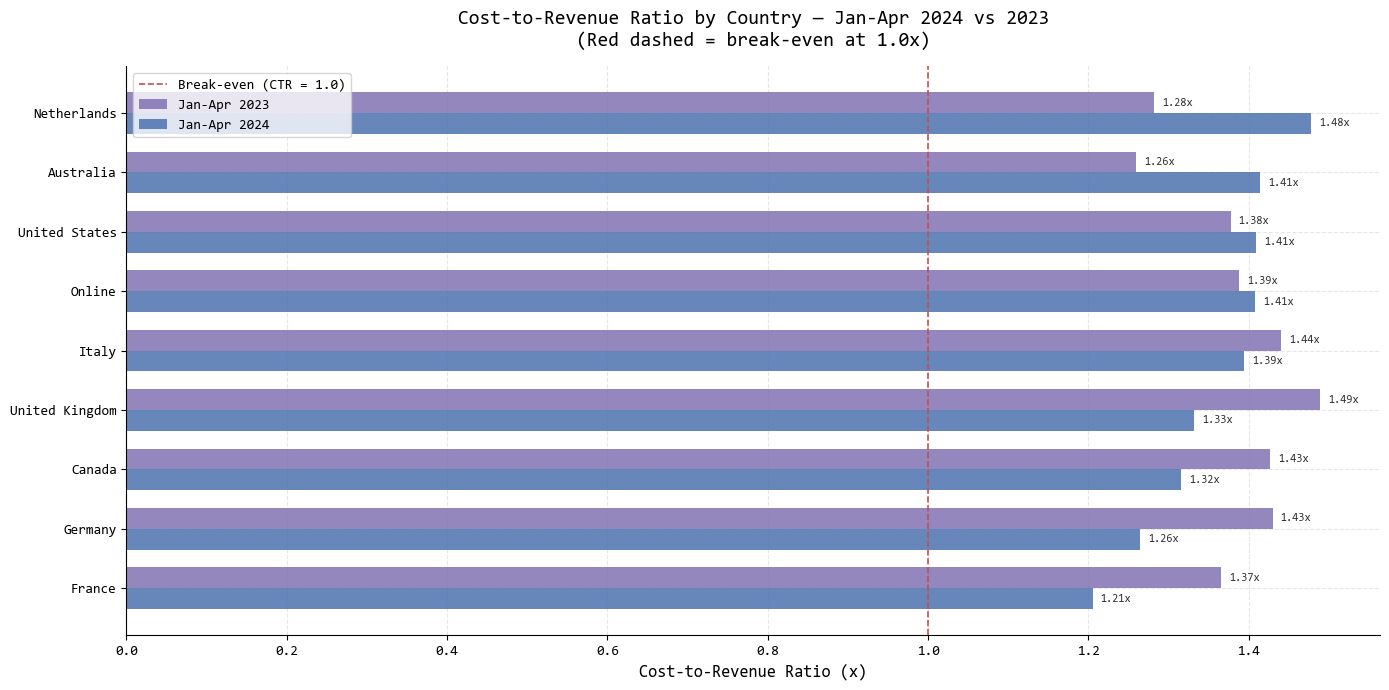

,Country,CTR_2023,CTR_2024,Change
0,France,1.366x,1.206x,-0.161x
1,Germany,1.430x,1.265x,-0.165x
2,Canada,1.427x,1.316x,-0.111x
3,United Kingdom,1.490x,1.332x,-0.157x
4,Italy,1.440x,1.395x,-0.046x
5,Online,1.388x,1.408x,+0.020x
6,United States,1.377x,1.409x,+0.032x
7,Australia,1.260x,1.415x,+0.155x
8,Netherlands,1.283x,1.478x,+0.195x


In [ ]:
# 2.L3.07 - Cost-to-revenue ratio by country 2023 vs 2024
df_ctr_raw = pd.read_sql("""
    SELECT
        st.CountryName,
        YEAR(s.OrderDate) AS Year,
        SUM(s.UnitCost * s.Quantity) / NULLIF(SUM(s.NetPrice), 0) AS CostToRevenue
    FROM Data.Sales s
    JOIN Data.Store st ON s.StoreKey = st.StoreKey
    WHERE MONTH(s.OrderDate) BETWEEN 1 AND 4
      AND YEAR(s.OrderDate) IN (2023, 2024)
    GROUP BY st.CountryName, YEAR(s.OrderDate)
""", cnxn)

df_ctr = df_ctr_raw.pivot(index='CountryName', columns='Year', values='CostToRevenue').reset_index()
df_ctr.columns = ['Country', 'CTR_2023', 'CTR_2024']
df_ctr['Change'] = df_ctr['CTR_2024'] - df_ctr['CTR_2023']
df_ctr = df_ctr.sort_values('CTR_2024', ascending=True).reset_index(drop=True)

import matplotlib.pyplot as plt, matplotlib as mpl, numpy as np
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(df_ctr))
w = 0.35
bars23 = ax.barh(x + w/2, df_ctr['CTR_2023'], w, label='Jan-Apr 2023', color='#8172B3', alpha=0.85)
bars24 = ax.barh(x - w/2, df_ctr['CTR_2024'], w, label='Jan-Apr 2024', color='#4C72B0', alpha=0.85)

for bar, v in zip(bars23, df_ctr['CTR_2023']):
    ax.text(bar.get_width() + 0.01, bar.get_y()+bar.get_height()/2,
            f'{v:.2f}x', ha='left', va='center', fontsize=8, color='#333333', fontfamily='Consolas')
for bar, v in zip(bars24, df_ctr['CTR_2024']):
    ax.text(bar.get_width() + 0.01, bar.get_y()+bar.get_height()/2,
            f'{v:.2f}x', ha='left', va='center', fontsize=8, color='#333333', fontfamily='Consolas')

ax.axvline(1.0, color='#C44E52', linewidth=1.2, linestyle='--', label='Break-even (CTR = 1.0)')
ax.set_yticks(x)
ax.set_yticklabels(df_ctr['Country'], fontsize=10, fontfamily='Consolas')
ax.set_xlabel('Cost-to-Revenue Ratio (x)', fontsize=12, fontfamily='Consolas')
ax.set_title('Cost-to-Revenue Ratio by Country — Jan-Apr 2024 vs 2023\n(Red dashed = break-even at 1.0x)', fontsize=14, fontfamily='Consolas', pad=15)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

display(df_ctr.style.format({'CTR_2023':'{:.3f}x','CTR_2024':'{:.3f}x','Change':'{:+.3f}x'}))

### Key Insight — 2.L3.07
**Every single market spends more than $1 in cost for every $1 of revenue — the lowest cost-to-revenue ratio is France at 1.37x in 2024, meaning the company spends $1.37 to earn $1 everywhere it operates.**
Netherlands worsened the most (1.28x to 1.48x), while France (1.21x to 1.37x — worsening despite margin pp improvement in 2.L3.02, reflecting revenue volume mix effects), UK (1.49x to 1.33x), Germany (1.43x to 1.26x), and Canada (1.43x to 1.32x) all improved.
No market is close to break-even (1.0x). This is a structural cost problem requiring supplier renegotiation or product repricing — operational efficiency improvements alone cannot close a 30–48% cost overage.

> **Analysis Limitation:** Multi-currency sales not FX-normalized; ratio reflects transaction currency mix, which may exaggerate or understate the true cost overage in USD terms.